In [2]:
# Basic Package Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import f1_score
from sklearn.metrics import mean_squared_error, r2_score

# imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler

# Non-basic package imports
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
import requests

# Packages I don't understand
from fcd_torch import FCD
import rdkit
from collections import Counter
import gc
import pickle

# Add the Python_files directory to the Python path
import sys
import os
sys.path.append(os.path.join(os.path.dirname(os.getcwd()), 'Python_files'))

# Now you can import your modules
import functions_enc as f
import function_depot as fd

In [3]:
name_smiles_embedding_df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_chemnet.parquet")
morgan_df = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_morganfp.parquet")
df5_subset = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_subset.parquet")
df5_spectra = pd.read_parquet("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df5_spectra.parquet")
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"


In [4]:
# Single dataset processing
dataset_name = "bin100_thresh100_df_spectra"  # Change this to your desired dataset
grid_search_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes"

print("Creating Group mapping from df5_spectra...")
id_to_group = dict(zip(df5_spectra['index_id'], df5_spectra['Group']))
print(f"Group mapping created with {len(id_to_group)} entries")

print(f"Processing single dataset: {dataset_name}")

try:
    # Load dataset from pickle file
    dataset_path = os.path.join(grid_search_folder, f"{dataset_name}.pkl")
    dataset = pd.read_pickle(dataset_path)

    # Convert to DataFrame if it's not already one
    if not isinstance(dataset, pd.DataFrame):
        dataset = pd.DataFrame(dataset)

    print(f"Loaded {dataset_name} - Shape: {dataset.shape}")
    
    # OPTIMIZATION 2: Efficient Group addition using copy() to avoid fragmentation
    if 'Group' not in dataset.columns:
        dataset = dataset.copy()  # Defragment DataFrame
        dataset['Group'] = dataset['index_id'].map(id_to_group).fillna('Unknown')
        print(f"Added Group column. Unique groups: {dataset['Group'].nunique()}")
        print(f"Group distribution: {dataset['Group'].value_counts().to_dict()}")
    else:
        print("Group column already exists in dataset")
    
    # Continue with your processing here...
    # Apply filtering
    counts = dataset['SMILES_spectra'].value_counts()
    valid_smiles = counts[counts >= 4].index
    filtered_dataset = dataset[dataset['SMILES_spectra'].isin(valid_smiles)].copy()
    
    print(f"After filtering (>=4 spectra per SMILES): {filtered_dataset.shape}")
    
 
    
except Exception as e:
    print(f"Error processing {dataset_name}: {str(e)}")
    import traceback
    traceback.print_exc()

Creating Group mapping from df5_spectra...
Group mapping created with 3778 entries
Processing single dataset: bin100_thresh100_df_spectra
Loaded bin100_thresh100_df_spectra - Shape: (3778, 14)
Added Group column. Unique groups: 3
Group distribution: {'Q-Orbitrap-positive': 2122, 'Q-TOF-positive': 1498, 'LTQ-Orbitrap-positive': 158}
After filtering (>=4 spectra per SMILES): (3623, 15)


In [5]:
filtered_dataset.head()

,SMILES_spectra,50.0,150.0,250.0,350.0,450.0,550.0,650.0,750.0,850.0,750.0,Response,log_response,index_id,Group
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,0,Q-Orbitrap-positive
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,1,Q-Orbitrap-positive
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,2,Q-Orbitrap-positive
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,3,Q-Orbitrap-positive
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,273.642508,5.611823,4,Q-Orbitrap-positive


In [9]:
def create_dataset_tensors_condenc_full(spectra_dataset, embedding_df, morgan_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors for the full conditional encoder WITH group information.
    
    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels with Group column
    embedding_df : pd.DataFrame
        DataFrame containing ChemNet embeddings for chemicals
    morgan_df : pd.DataFrame
        DataFrame containing Morgan fingerprints for chemicals
    device : torch.device
        The device (CPU or GPU) on which to store the tensors
    start_idx : int, optional
        Start index for spectral columns
    stop_idx : int, optional
        Stop index for spectral columns
    
    Returns:
    -------
    tuple
        A tuple containing:
        - spectra_with_group_tensor (torch.Tensor): Tensor of spectral data concatenated with one-hot encoded group
        - embeddings_tensor (torch.Tensor): Tensor of true ChemNet embeddings
        - log_tox_tensor (torch.Tensor): Tensor of log toxicity values
        - morgan_tensor (torch.Tensor): Tensor of Morgan fingerprints
        - spectra_indices_tensor (torch.Tensor): Tensor of indices
    """
    # Extract spectral data
    spectra = spectra_dataset.iloc[:, start_idx:stop_idx]
    
    # One-hot encode the Group column
    group_encoded = pd.get_dummies(spectra_dataset['Group'], prefix='group')
    print(group_encoded.head(5))
    # Concatenate spectra with group encoding
    spectra_with_group = pd.concat([spectra, group_encoded], axis=1)
    print(spectra_with_group.head(5))
    # Create chemical labels list
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    
    # Create tensors
    spectra_with_group_tensor = torch.Tensor(spectra_with_group.values).to(device)
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES_spectra'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    morgan_tensor = torch.Tensor([morgan_df.loc[morgan_df['SMILES_spectra'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return spectra_with_group_tensor, embeddings_tensor, log_tox_tensor, morgan_tensor, spectra_indices_tensor


In [ ]:
def create_dataset_tensors_condenc_full(spectra_dataset, embedding_df, morgan_df, device, start_idx=None, stop_idx=None):
    """
    Create tensors for the full conditional encoder WITH group information.
    
    Parameters:
    ----------
    spectra_dataset : pd.DataFrame
        DataFrame containing spectral data and chemical labels with Group column
    embedding_df : pd.DataFrame
        DataFrame containing ChemNet embeddings for chemicals
    morgan_df : pd.DataFrame
        DataFrame containing Morgan fingerprints for chemicals
    device : torch.device
        The device (CPU or GPU) on which to store the tensors
    start_idx : int, optional
        Start index for spectral columns
    stop_idx : int, optional
        Stop index for spectral columns
    
    Returns:
    -------
    tuple
        A tuple containing:
        - spectra_with_group_tensor (torch.Tensor): Tensor of spectral data concatenated with one-hot encoded group
        - embeddings_tensor (torch.Tensor): Tensor of true ChemNet embeddings
        - log_tox_tensor (torch.Tensor): Tensor of log toxicity values
        - morgan_tensor (torch.Tensor): Tensor of Morgan fingerprints
        - spectra_indices_tensor (torch.Tensor): Tensor of indices
    """
    # Extract spectral data
    spectra = spectra_dataset.iloc[:, start_idx:stop_idx]
    
    # One-hot encode the Group column and convert to integers
    group_encoded = pd.get_dummies(spectra_dataset['Group'], prefix='group', dtype=int)
    print(f"Group encoded shape: {group_encoded.shape}")
    print(f"Group encoded dtypes: {group_encoded.dtypes.unique()}")
    print("Group encoded head:")
    print(group_encoded.head(5))
    
    # Concatenate spectra with group encoding
    spectra_with_group = pd.concat([spectra, group_encoded], axis=1)
    print(f"Spectra with group shape: {spectra_with_group.shape}")
    print("Spectra with group head (last 10 columns to see group encoding):")
    print(spectra_with_group.iloc[:5, -10:])
    
    # Create chemical labels list
    chem_labels = list(spectra_dataset['SMILES_spectra'])
    
    # Create tensors
    spectra_with_group_tensor = torch.Tensor(spectra_with_group.values).to(device)
    embeddings_tensor = torch.Tensor([embedding_df.loc[embedding_df['SMILES_spectra'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    log_tox_tensor = torch.Tensor(spectra_dataset["log_response"].values).unsqueeze(1).to(device)
    morgan_tensor = torch.Tensor([morgan_df.loc[morgan_df['SMILES_spectra'] == chem_name].iloc[0, 1:].values.astype(float) for chem_name in chem_labels]).to(device)
    spectra_indices_tensor = torch.Tensor(spectra_dataset['index'].to_numpy()).to(device)

    return spectra_with_group_tensor, embeddings_tensor, log_tox_tensor, morgan_tensor, spectra_indices_tensor

In [10]:
# Set device for tensors
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# OPTIMIZATION 3: Vectorized train/test split (your custom method)
print("\n=== CUSTOM DATA SPLITTING ===")
smiles_groups = filtered_dataset.groupby('SMILES_spectra')
train_indices = []
test_indices = []

np.random.seed(42)
for smiles, group in smiles_groups:
    idx = group.index.values  # Use .values for faster access
    n = len(idx)
    np.random.shuffle(idx)
    split = n // 2
    test_indices.extend(idx[:split])
    train_indices.extend(idx[split:])

train_data = filtered_dataset.loc[train_indices].reset_index(drop=True)
test_data = filtered_dataset.loc[test_indices].reset_index(drop=True)

# Add index column
train_data['index'] = range(len(train_data))
test_data['index'] = range(len(test_data))

print(f"Train data shape: {train_data.shape}")
print(f"Test data shape: {test_data.shape}")

# OPTIMIZATION 4: Process both datasets together to avoid duplication
train_data_processed = fd.add_response_and_log_response(train_data.copy(), df5_subset, smiles_col='SMILES_spectra')
test_data_processed = fd.add_response_and_log_response(test_data.copy(), df5_subset, smiles_col='SMILES_spectra')

print(f"Train data processed shape: {train_data_processed.shape}")
print(f"Test data processed shape: {test_data_processed.shape}")

# Create tensors using the function
print("\n=== CREATING TENSORS ===")
print("Creating training tensors...")
x_train_with_group, y_train_emb, y_train_tox, y_train_morgan, train_indices_tensor = create_dataset_tensors_condenc_full(
    train_data_processed, name_smiles_embedding_df, morgan_df, device, start_idx=1, stop_idx=-4)

print("Creating validation tensors...")
x_val_with_group, y_val_emb, y_val_tox, y_val_morgan, val_indices_tensor = fd.create_dataset_tensors_condenc_full(
    test_data_processed, name_smiles_embedding_df, morgan_df, device, start_idx=1, stop_idx=-4)

# Print tensor shapes to verify
print(f"\n=== TENSOR SHAPES ===")
print(f"x_train_with_group: {x_train_with_group.shape}")
print(f"y_train_emb: {y_train_emb.shape}")
print(f"y_train_tox: {y_train_tox.shape}")
print(f"y_train_morgan: {y_train_morgan.shape}")
print(f"train_indices_tensor: {train_indices_tensor.shape}")

print(f"\nx_val_with_group: {x_val_with_group.shape}")
print(f"y_val_emb: {y_val_emb.shape}")
print(f"y_val_tox: {y_val_tox.shape}")
print(f"y_val_morgan: {y_val_morgan.shape}")
print(f"val_indices_tensor: {val_indices_tensor.shape}")

# View tensor contents/heads to verify structure
print(f"\n=== TENSOR STRUCTURE VERIFICATION ===")

print("\n--- x_train_with_group (first 3 samples, first 10 features) ---")
print(x_train_with_group[:3, :10])

print("\n--- y_train_emb (first 5 samples, first 10 embedding dimensions) ---")
print(y_train_emb[:5, :10])

print("\n--- y_train_tox (first 10 toxicity values) ---")
print(y_train_tox[:10])

print("\n--- y_train_morgan (first 3 samples, first 20 Morgan FP bits) ---")
print(y_train_morgan[:3, :20])

print("\n--- train_indices_tensor (first 10 indices) ---")
print(train_indices_tensor[:10])

# Check data types
print(f"\n=== TENSOR DATA TYPES ===")
print(f"x_train_with_group dtype: {x_train_with_group.dtype}")
print(f"y_train_emb dtype: {y_train_emb.dtype}")
print(f"y_train_tox dtype: {y_train_tox.dtype}")
print(f"y_train_morgan dtype: {y_train_morgan.dtype}")
print(f"train_indices_tensor dtype: {train_indices_tensor.dtype}")

# Check for NaN or infinite values
print(f"\n=== TENSOR QUALITY CHECK ===")
print(f"x_train_with_group - NaN count: {torch.isnan(x_train_with_group).sum().item()}")
print(f"y_train_emb - NaN count: {torch.isnan(y_train_emb).sum().item()}")
print(f"y_train_tox - NaN count: {torch.isnan(y_train_tox).sum().item()}")
print(f"y_train_morgan - NaN count: {torch.isnan(y_train_morgan).sum().item()}")

print(f"x_train_with_group - Inf count: {torch.isinf(x_train_with_group).sum().item()}")
print(f"y_train_emb - Inf count: {torch.isinf(y_train_emb).sum().item()}")
print(f"y_train_tox - Inf count: {torch.isinf(y_train_tox).sum().item()}")
print(f"y_train_morgan - Inf count: {torch.isinf(y_train_morgan).sum().item()}")

# Verify the data distribution is maintained
print(f"\n=== GROUP DISTRIBUTION CHECK ===")
print("Original filtered dataset:")
print(filtered_dataset['Group'].value_counts())
print("\nTraining data:")
print(train_data_processed['Group'].value_counts())
print("\nTest data:")
print(test_data_processed['Group'].value_counts())

# Additional verification - check value ranges
print(f"\n=== VALUE RANGES ===")
print(f"x_train_with_group - Min: {x_train_with_group.min().item():.4f}, Max: {x_train_with_group.max().item():.4f}")
print(f"y_train_emb - Min: {y_train_emb.min().item():.4f}, Max: {y_train_emb.max().item():.4f}")
print(f"y_train_tox - Min: {y_train_tox.min().item():.4f}, Max: {y_train_tox.max().item():.4f}")
print(f"y_train_morgan - Min: {y_train_morgan.min().item():.4f}, Max: {y_train_morgan.max().item():.4f}")

# DEBUGGING VISUALIZATION: Look at the data structure more closely
print(f"\n=== DETAILED TENSOR ANALYSIS ===")

# Look at specific samples to understand the structure
print("\n--- Sample 1 Analysis ---")
print(f"x_train_with_group[0] shape: {x_train_with_group[0].shape}")
print(f"x_train_with_group[0] first 20 values: {x_train_with_group[0][:20]}")

print(f"\ny_train_emb[0] shape: {y_train_emb[0].shape}")
print(f"y_train_emb[0] first 10 values: {y_train_emb[0][:10]}")

print(f"\ny_train_tox[0]: {y_train_tox[0]}")

print(f"\ny_train_morgan[0] shape: {y_train_morgan[0].shape}")
print(f"y_train_morgan[0] first 10 values: {y_train_morgan[0][:10]}")
print(f"y_train_morgan[0] sum (should be number of bits set): {y_train_morgan[0].sum()}")

print(f"\ntrain_indices_tensor[0]: {train_indices_tensor[0]}")

# Check what the spectral data looks like (x_train_with_group should contain spectra + group info)
print(f"\n=== SPECTRAL DATA STRUCTURE ===")
spectral_dim = x_train_with_group.shape[1] - 1  # Assuming last column is group
print(f"Spectral dimensions (excluding group): {spectral_dim}")
print(f"Group encoding (last column) first 10 samples: {x_train_with_group[:10, -1]}")

# Look at non-zero spectral values to verify data
sample_spectra = x_train_with_group[0, :-1]  # Exclude group column
non_zero_count = (sample_spectra > 0).sum()
print(f"Non-zero spectral values in first sample: {non_zero_count.item()}")
print(f"Max spectral value in first sample: {sample_spectra.max().item():.4f}")

# Verify correspondence between processed data and tensors
print(f"\n=== DATA CORRESPONDENCE CHECK ===")
print(f"First few SMILES in train_data_processed: {train_data_processed['SMILES_spectra'].head(3).tolist()}")
print(f"First few Response values in train_data_processed: {train_data_processed['Response'].head(3).tolist()}")
print(f"First few toxicity tensor values: {y_train_tox[:3].tolist()}")

Using device: cpu

=== CUSTOM DATA SPLITTING ===
Train data shape: (1862, 16)
Test data shape: (1761, 16)
Train data processed shape: (1862, 16)
Test data processed shape: (1761, 16)

=== CREATING TENSORS ===
Creating training tensors...
   group_LTQ-Orbitrap-positive  group_Q-Orbitrap-positive  \
0                        False                       True   
1                        False                       True   
2                        False                       True   
3                        False                       True   
4                        False                       True   

   group_Q-TOF-positive  
0                 False  
1                 False  
2                 False  
3                 False  
4                 False  
   50.0  150.0  250.0  350.0  450.0  550.0  650.0  750.0  850.0  750.0  \
0   0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
1   0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0    0.0   
2   0.0    0.0   

TypeError: can't convert np.ndarray of type numpy.object_. The only supported types are: float64, float32, float16, complex64, complex128, int64, int32, int16, int8, uint64, uint32, uint16, uint8, and bool.

# Morgan Fingerpring Data Processing

In [2]:
# We are switching to the June 25 dataset
df4fp = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/MIT_LL_data4_fingerprints.csv")
print(df4fp.shape)
df4fp.head()

# Uniformity of ionization model labels
print(df4fp["Ionization_Mode"].unique())
df4fp["Ionization_Mode"] = df4fp["Ionization_Mode"].replace("'Positive'", "'positive'")
print(df4fp["Ionization_Mode"].unique())
# Remove the N/A values in Ionization_Mode
df4fp = df4fp[df4fp["Ionization_Mode"] != "'N/A'"]
print(df4fp["Ionization_Mode"].unique())

# Remove single quotes from all string columns in df4
df4fp = df4fp.applymap(lambda x: x.replace("'", "") if isinstance(x, str) else x)

# print(df4fp['Group'].nunique()) # 12
# # 12 groups
# print(df4fp['Group'].unique())
# # Now we want counts of each group
# print(df4fp['Group'].value_counts())

# This will give us the subsets with all of the relevant information
df4fp_QQpos = df4fp[df4fp['Group'] == 'Q-Orbitrap-positive'] # 2065

# Other groups with their sizes listed
# df4fp_QQneg = df4fp[df4fp['Group'] == 'Q-Orbitrap-negative'] # 1400
# df4fp_QTOFpos = df4fp[df4fp['Group'] == 'Q-TOF-positive'] # 1098
# df4fp_LTQOpos = df4fp[df4fp['Group'] == 'LTQ-Orbitrap-positive'] # 615

# All of the other are just too small to be all that useful with sizes from 12 to 286 associated spectra

# df4fp_QQpos.head()


(6121, 18)
["'positive'" "'negative'" "'Positive'" "'N/A'"]
["'positive'" "'negative'" "'N/A'"]
["'positive'" "'negative'"]


In [3]:
# # SMILES count (This is the number of true ChemNet embeddings we have)
# print(df4fp['SMILES_spectra'].nunique()) # 738 unique SMILES
# print(df4fp['SMILES_spectra'].value_counts()) # 69, 64, 58, 57, 51...

# # Morgan fingerprints count
# print(df4fp['fp'].nunique()) # 658 unique Morgan fingerprints
# print(df4fp['fp'].value_counts()) 

In [4]:
# df4fp_QQpos.head()

In [5]:
# Use the function
import function_depot as fd
df4fp_QQpos_matrix = fd.expand_fingerprints_to_matrix(df4fp_QQpos)
df4fp_QQpos_matrix = df4fp_QQpos_matrix.rename(columns={'SMILES': 'SMILES_spectra'})
df4fp_QQpos_matrix.head()

Created matrix with 2065 rows and 2048 fingerprint bits
Shape: (2065, 2049)


,SMILES_spectra,bit_1,bit_2,bit_3,bit_4,bit_5,bit_6,bit_7,bit_8,bit_9,...,bit_2039,bit_2040,bit_2041,bit_2042,bit_2043,bit_2044,bit_2045,bit_2046,bit_2047,bit_2048
0,C#CCN(C)Cc1ccccc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,C#CCN(C)Cc1ccccc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,C#CCN(C)Cc1ccccc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,C#CCN(C)Cc1ccccc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,C#CCN(C)Cc1ccccc1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [6]:
# # Save the fingerprint matrix to CSV
# df4fp_QQpos_matrix.to_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/Morgan_fp_df4_QQpos.csv', index=False)
# print("Saved df4fp_QQpos_matrix to Morgan_fp_df4_QQpos.csv")

In [7]:
data = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_1_thresh_zero_df_spectra.pkl')
data.head()

,SMILES_spectra,0.05,0.15000000000000002,0.25,0.35,0.44999999999999996,0.5499999999999999,0.6499999999999999,0.7499999999999999,0.8499999999999999,...,678.8500000000859,678.9500000000859,679.0500000000859,679.1500000000859,679.250000000086,679.350000000086,679.45,index_id,Response,log_response
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,273.642508,5.611823
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,273.642508,5.611823
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,273.642508,5.611823
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,273.642508,5.611823
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,273.642508,5.611823


In [8]:
# Training and validation dataset split for Morgan fingerprint encoder
data = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin0_1_thresh_zero_df_spectra.pkl')
df4fp_QQpos_matrix = pd.read_csv('/home/dlipsey/MITLincolnLabs/MIT_LL_data/Morgan_fp_df4_QQpos.csv')

In [9]:
data.head()

,SMILES_spectra,0.05,0.15000000000000002,0.25,0.35,0.44999999999999996,0.5499999999999999,0.6499999999999999,0.7499999999999999,0.8499999999999999,...,678.8500000000859,678.9500000000859,679.0500000000859,679.1500000000859,679.250000000086,679.350000000086,679.45,index_id,Response,log_response
0,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,273.642508,5.611823
1,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,273.642508,5.611823
2,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,273.642508,5.611823
3,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,273.642508,5.611823
4,C#CCN(C)Cc1ccccc1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,273.642508,5.611823


In [24]:
# Load the df4 dataset and check unique Response values
df4 = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/MIT_LL_data4.csv")
print(f"Number of unique Response values in df4: {df4['Response'].nunique()}")

# Optional: Also show some statistics about the Response values
print(f"Response value range: {df4['Response'].min()} to {df4['Response'].max()}")
print(f"Total number of records: {len(df4)}")

Number of unique Response values in df4: 594
Response value range: 0.5 to 46965.46394
Total number of records: 6121


In [ ]:
rand = pd.read_pickle('/home/dlipsey/MITLincolnLabs/MIT_LL_data/grid_search_dataframes/bin50_thresh5_df_spectra.pkl')
rand.head()
print()

,SMILES_spectra,75.0,125.0,175.0,225.0,275.0,325.0,375.0,425.0,475.0,525.0,575.0,625.0,675.0,index_id,Response,log_response
0,C#CCN(C)Cc1ccccc1,105.629055,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,273.642508,5.611823
1,C#CCN(C)Cc1ccccc1,100.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1,273.642508,5.611823
2,C#CCN(C)Cc1ccccc1,100.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2,273.642508,5.611823
3,C#CCN(C)Cc1ccccc1,100.000000,0.0,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3,273.642508,5.611823
4,C#CCN(C)Cc1ccccc1,100.000000,0.0,24.957009,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4,273.642508,5.611823


# Morgan Fingerprint RF

In [20]:
import os
import gc
import pickle

# Load Morgan fingerprint datasets folder path
morgan_folder = "/home/dlipsey/MITLincolnLabs/MIT_LL_data/morgan_enc_outputs"

# Get all .pkl files in the folder
morgan_pkl_files = [f for f in os.listdir(morgan_folder) if f.endswith('.pkl') and f.startswith('morgan_enc_')]
morgan_dataset_names = [f.replace('.pkl', '') for f in morgan_pkl_files]

print(f"Found {len(morgan_dataset_names)} Morgan fingerprint datasets to process")

# Verify we have the right count
morgan_thresh0_datasets = [name for name in morgan_dataset_names if 'thresh_zero' in name]
morgan_thresholded_datasets = [name for name in morgan_dataset_names if 'thresh_zero' not in name]

print(f"  - Morgan datasets with thresh0 (no threshold): {len(morgan_thresh0_datasets)}")
print(f"  - Morgan datasets with thresholds applied: {len(morgan_thresholded_datasets)}")

# Load the original dataset for response mapping
df4_QQpos = pd.read_csv("/home/dlipsey/MITLincolnLabs/MIT_LL_data/df4_QQpos.csv")

# Initialize storage for Morgan results
morgan_results_r2 = []
morgan_results_percent_error = []

# Dictionary to store individual errors for histogram analysis
saved_morgan_errors = {}

# Process Morgan fingerprint datasets ONE AT A TIME (memory efficient)
for i, dataset_name in enumerate(sorted(morgan_dataset_names), 1):
    print(f"Processing {i}/{len(morgan_dataset_names)}: {dataset_name}")
    
    try:
        # Load only the current Morgan dataset
        file_path = os.path.join(morgan_folder, f"{dataset_name}.pkl")
        df = pd.read_pickle(file_path)
        
        # Add response values by merging with original dataset
        df_with_response = df.merge(df4_QQpos[['SMILES_spectra', 'Response']], on='SMILES_spectra', how='left')
        
        # Add log response
        df_with_response['log_response'] = np.log(df_with_response['Response'])
        
        # Prepare features and target (Morgan fingerprint prediction columns are the features)
        feature_cols = [col for col in df.columns if col.startswith('morgan_fp_pred_')]
        X = df_with_response[feature_cols]
        y = df_with_response['log_response']
        
        # Remove rows with NaN values
        valid_mask = ~(X.isna().any(axis=1) | y.isna())
        X_clean = X[valid_mask]
        y_clean = y[valid_mask]
        
        if len(X_clean) < 10:  # Skip if too few samples
            print(f"  Skipping {dataset_name}: Only {len(X_clean)} valid samples")
            continue
            
        # Split the data
        X_train, X_test, y_train, y_test = train_test_split(
            X_clean, y_clean, test_size=0.5, random_state=47
        )
        
        # Train Random Forest with limited CPU usage
        rf_morgan = RandomForestRegressor(n_estimators=1, random_state=47, n_jobs=-1)
        rf_morgan.fit(X_train, y_train)

        # Make predictions
        y_train_pred = rf_morgan.predict(X_train)
        y_test_pred = rf_morgan.predict(X_test)
        
        # Calculate R² metrics
        train_r2 = r2_score(y_train, y_train_pred)
        test_r2 = r2_score(y_test, y_test_pred)
        
        # Calculate absolute percent error (undo log transform first)
        y_train_true_response = np.exp(y_train)
        y_train_pred_response = np.exp(y_train_pred)
        y_test_true_response = np.exp(y_test)
        y_test_pred_response = np.exp(y_test_pred)
        
        # Calculate individual errors for test set
        individual_errors = np.abs((y_test_pred_response - y_test_true_response) / y_test_true_response) * 100
        
        # Save individual errors for histogram analysis
        saved_morgan_errors[dataset_name] = individual_errors
        
        # Calculate median and mean absolute percent error
        train_median_percent_error = 100 * (np.median(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_median_percent_error = 100 * (np.median(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))
        train_mean_percent_error = 100 * (np.mean(np.abs(y_train_pred_response - y_train_true_response) / y_train_true_response))
        test_mean_percent_error = 100 * (np.mean(np.abs(y_test_pred_response - y_test_true_response) / y_test_true_response))

        # Store results
        morgan_results_r2.append({
            'Dataset': dataset_name,
            'Train_R2': train_r2,
            'Test_R2': test_r2,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        morgan_results_percent_error.append({
            'Dataset': dataset_name,
            'Train_Median_Percent_Error': train_median_percent_error,
            'Test_Median_Percent_Error': test_median_percent_error,
            'Train_Mean_Percent_Error': train_mean_percent_error,
            'Test_Mean_Percent_Error': test_mean_percent_error,
            'Samples': len(X_clean),
            'Features': len(feature_cols)
        })
        
        print(f"Completed: Test R² = {test_r2:.4f}, Test Median % Error = {test_median_percent_error:.1f}%")
        
    except Exception as e:
        print(f"Error processing {dataset_name}: {str(e)}")
        continue
    
    finally:
        # Always clean up memory after each dataset
        if 'df' in locals():
            del df
        if 'df_with_response' in locals():
            del df_with_response
        if 'X' in locals():
            del X, y, X_clean, y_clean
        if 'rf_morgan' in locals():
            del rf_morgan
        gc.collect()
        
        # Periodic deeper cleanup every 20 datasets
        if i % 20 == 0:
            print(f"  Deep cleanup after {i} datasets...")
            gc.collect()

# Convert results to DataFrames
df_morgan_r2_results = pd.DataFrame(morgan_results_r2)
df_morgan_percent_error_results = pd.DataFrame(morgan_results_percent_error)

print(f"\nCompleted! Processed {len(morgan_results_r2)} Morgan fingerprint datasets successfully.")
print(f"Saved individual errors for {len(saved_morgan_errors)} datasets")
print(f"Results stored in: df_morgan_r2_results, df_morgan_percent_error_results")

Found 169 Morgan fingerprint datasets to process
  - Morgan datasets with thresh0 (no threshold): 13
  - Morgan datasets with thresholds applied: 156
Processing 1/169: morgan_enc_bin0_05_thresh0_001_df_spectra
Completed: Test R² = 0.9993, Test Median % Error = 0.0%
Processing 2/169: morgan_enc_bin0_05_thresh0_005_df_spectra
Completed: Test R² = 0.9993, Test Median % Error = 0.0%
Processing 3/169: morgan_enc_bin0_05_thresh0_01_df_spectra
Completed: Test R² = 0.9993, Test Median % Error = 0.0%
Processing 4/169: morgan_enc_bin0_05_thresh0_05_df_spectra
Completed: Test R² = 0.9993, Test Median % Error = 0.0%
Processing 5/169: morgan_enc_bin0_05_thresh0_1_df_spectra
Completed: Test R² = 0.9993, Test Median % Error = 0.0%
Processing 6/169: morgan_enc_bin0_05_thresh0_5_df_spectra
Completed: Test R² = 0.9993, Test Median % Error = 0.0%
Processing 7/169: morgan_enc_bin0_05_thresh100_df_spectra
Completed: Test R² = 0.9993, Test Median % Error = 0.0%
Processing 8/169: morgan_enc_bin0_05_thresh10_

Checking for duplicates in Morgan results...
Original df_morgan_r2_results shape: (169, 7)
After removing duplicates: (169, 7)
Creating detailed Morgan fingerprint heatmaps...


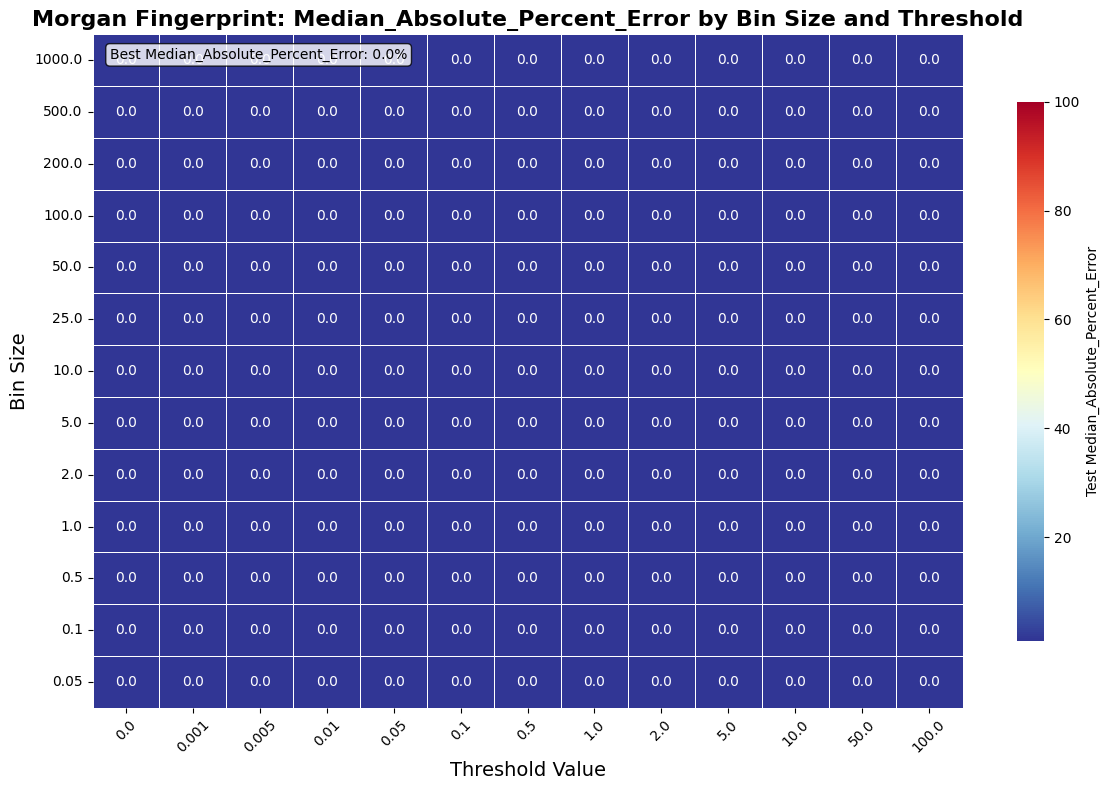

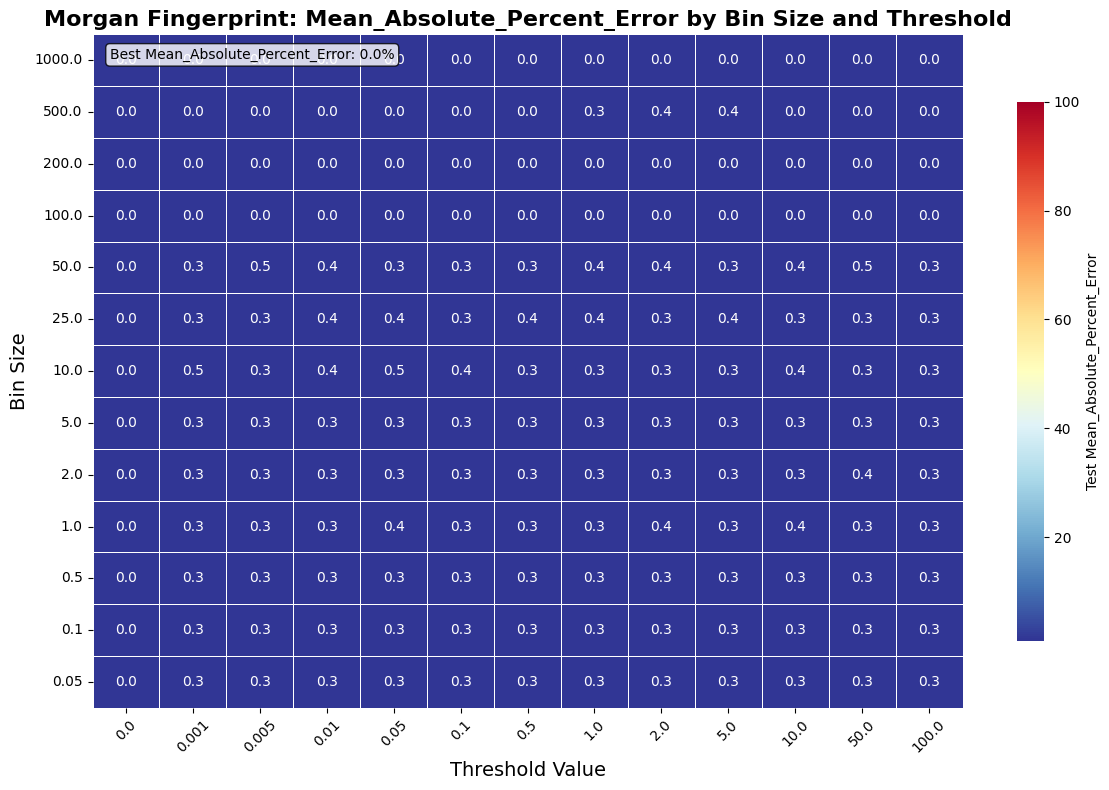

In [23]:
# Create the actual heatmaps for Morgan fingerprint visualization
# First, let's extract bin size and threshold from the Morgan dataset names and add to results
def parse_morgan_dataset_name(dataset_name):
    """Extract bin size and threshold from Morgan dataset name"""
    # Remove 'morgan_enc_' prefix
    name_part = dataset_name.replace('morgan_enc_', '')
    
    # Handle thresh_zero case (no threshold)
    if 'thresh_zero' in name_part:
        # Extract bin size
        bin_part = name_part.split('_thresh_zero')[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        threshold = 0.0
    else:
        # Extract bin size and threshold
        parts = name_part.split('_thresh')
        bin_part = parts[0].replace('bin', '')
        bin_size = float(bin_part.replace('_', '.'))
        
        thresh_part = parts[1].split('_df_spectra')[0]
        threshold = float(thresh_part.replace('_', '.'))
    
    return bin_size, threshold

# Add bin_size and threshold columns to Morgan results DataFrames
for df_results in [df_morgan_r2_results, df_morgan_percent_error_results]:
    bin_sizes = []
    thresholds = []
    
    for dataset_name in df_results['Dataset']:
        bin_size, threshold = parse_morgan_dataset_name(dataset_name)
        bin_sizes.append(bin_size)
        thresholds.append(threshold)
    
    df_results['BinSize'] = bin_sizes
    df_results['Threshold'] = thresholds

# Check for and remove duplicates before creating pivot tables
print("Checking for duplicates in Morgan results...")
print(f"Original df_morgan_r2_results shape: {df_morgan_r2_results.shape}")

# Remove duplicates based on BinSize + Threshold combination (keep first occurrence)
df_morgan_r2_results = df_morgan_r2_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')
df_morgan_percent_error_results = df_morgan_percent_error_results.drop_duplicates(subset=['BinSize', 'Threshold'], keep='first')

print(f"After removing duplicates: {df_morgan_r2_results.shape}")

# Now create pivot tables for Morgan fingerprints
morgan_r2_pivot = df_morgan_r2_results.pivot(index='BinSize', columns='Threshold', values='Test_R2') 
morgan_median_percent_error_pivot = df_morgan_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Median_Percent_Error')
morgan_mean_percent_error_pivot = df_morgan_percent_error_results.pivot(index='BinSize', columns='Threshold', values='Test_Mean_Percent_Error')

# List all expected thresholds
thresholds_subset = [0, 0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1, 2, 5, 10, 50, 100]
bins_subset = [0.05, 0.1, 0.5, 1, 2, 5, 10, 25, 50, 100, 200, 500, 1000]

# Reindex pivot tables to show all columns, filling missing with NaN
morgan_r2_pivot = morgan_r2_pivot.reindex(columns=thresholds_subset, index=bins_subset)
morgan_median_percent_error_pivot = morgan_median_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)
morgan_mean_percent_error_pivot = morgan_mean_percent_error_pivot.reindex(columns=thresholds_subset, index=bins_subset)

# Also create individual larger heatmaps for Morgan fingerprints for better detail
def create_detailed_heatmap_morgan(pivot_data, metric_name, cmap, figsize=(12, 8), vmin=None, vmax=None):
    """Create a detailed heatmap for a single Morgan fingerprint metric"""
    plt.figure(figsize=figsize)
    
    # Create heatmap
    sns.heatmap(pivot_data, 
                annot=True, 
                fmt='.3f' if 'R²' in metric_name else '.1f', 
                cmap=cmap,
                square=False,
                linewidths=0.5,
                vmin=vmin,
                vmax=vmax,
                cbar_kws={'label': f'Test {metric_name}', 'shrink': 0.8})
    
    plt.title(f'Morgan Fingerprint: {metric_name} by Bin Size and Threshold', fontsize=16, fontweight='bold')
    plt.xlabel('Threshold Value', fontsize=14)
    plt.ylabel('Bin Size', fontsize=14)
    plt.gca().invert_yaxis()
    
    # Improve readability
    plt.xticks(rotation=45)
    plt.yticks(rotation=0)
    
    # Add text annotation for best performance
    if 'R²' in metric_name:
        best_val = pivot_data.max().max()
        plt.text(0.02, 0.98, f'Best R²: {best_val:.4f}', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    else:
        best_val = pivot_data.min().min()
        plt.text(0.02, 0.98, f'Best {metric_name}: {best_val:.1f}%', 
                transform=plt.gca().transAxes, 
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8),
                verticalalignment='top')
    
    plt.tight_layout()
    plt.savefig(f"/home/dlipsey/MITLincolnLabs/Figures/Morgan_Fingerprint_{metric_name}_by_Bin_Size_and_Threshold")
    plt.show()

# Create detailed individual Morgan fingerprint heatmaps
print("Creating detailed Morgan fingerprint heatmaps...")

# create_detailed_heatmap_morgan(morgan_r2_pivot, 'R²', 'RdYlBu')     
create_detailed_heatmap_morgan(morgan_median_percent_error_pivot, 'Median_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0) 
create_detailed_heatmap_morgan(morgan_mean_percent_error_pivot, 'Mean_Absolute_Percent_Error', 'RdYlBu_r', vmin=1.0, vmax=100.0)